# 校园能源数据分析 Notebook

这个 Notebook 是 `energy_analysis.py` 的交互版，适合在 VS Code 里逐格运行和修改。

- 环境：项目虚拟环境 `.venv`（Python 3.11 + pandas + numpy + matplotlib）
- 数据：`data/monthly_energy_sample.csv`（模拟数据，练习用；请替换成真实数据）
- 内核：在 VS Code 右上角选择 **Python 3.11 (Energy Data Project)**
- 运行：点击 **Run All**

真实数据来源：国家统计局、国家能源局、中国电力企业联合会、IEA、Our World in Data。

> 提醒：示例数据是模拟的，正式报告必须注明“模拟数据，仅用于练习”，并从官方来源替换。

In [1]:
%matplotlib inline
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

# 自动找到项目根目录（包含 data 文件夹的目录）
def find_project_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "monthly_energy_sample.csv").exists():
            return p
    return start

BASE_DIR = find_project_root()
DATA_PATH = BASE_DIR / "data" / "monthly_energy_sample.csv"
OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR = OUT_DIR / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("项目目录：", BASE_DIR)
print("数据文件：", DATA_PATH)
print("输出目录：", OUT_DIR)
print("图表目录：", CHARTS_DIR)

SOURCE_NOTE = '内置示例数据（模拟），仅用于练习'
PERIODS = 12


项目目录： C:\Users\Lenovo\Documents\New project\Three_Year_Plan_2026_2029\Energy_Data_Project
数据文件： C:\Users\Lenovo\Documents\New project\Three_Year_Plan_2026_2029\Energy_Data_Project\data\monthly_energy_sample.csv
输出目录： C:\Users\Lenovo\Documents\New project\Three_Year_Plan_2026_2029\Energy_Data_Project\output
图表目录： C:\Users\Lenovo\Documents\New project\Three_Year_Plan_2026_2029\Energy_Data_Project\output\charts


In [2]:
DATE_COL = "month"
VALUE_COL = "electricity_mwh"
TEMP_COL = "temperature_c"
OCCUPANCY_COL = "occupancy_rate"


def load_data(path: Path) -> pd.DataFrame:
    """读取 CSV，并把月份列转成日期类型。"""
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]

    if DATE_COL not in df.columns:
        raise ValueError(f"数据里缺少月份列：{DATE_COL}")
    if VALUE_COL not in df.columns:
        raise ValueError(f"数据里缺少用电量列：{VALUE_COL}")

    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[DATE_COL])
    duplicate_count = int(df[DATE_COL].duplicated().sum())
    if duplicate_count:
        print(f"发现 {duplicate_count} 个重复月份，已保留每个月的最后一条记录。")
        df = df.drop_duplicates(subset=[DATE_COL], keep="last")
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    return df


def clean_data(df: pd.DataFrame):
    """数值列转数字，用时间插值补缺失值，并记录缺失情况。"""
    numeric_cols = [
        col for col in [VALUE_COL, TEMP_COL, OCCUPANCY_COL] if col in df.columns
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    missing_before = {
        str(col): int(count)
        for col, count in df[numeric_cols].isna().sum().items()
    }

    df = df.set_index(DATE_COL)
    df[numeric_cols] = df[numeric_cols].interpolate(
        method="time", limit_direction="both"
    )
    df[numeric_cols] = df[numeric_cols].ffill().bfill()
    df = df.reset_index()
    return df, missing_before


def add_metrics(df: pd.DataFrame, periods: int = 12) -> pd.DataFrame:
    """计算环比、同比和移动平均；periods 由数据频率决定。"""
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    df["mom_growth"] = df[VALUE_COL].pct_change(periods=1)
    df["yoy_growth"] = df[VALUE_COL].pct_change(periods=periods)
    window = max(2, int(periods))
    df["ma12"] = df[VALUE_COL].rolling(window=window, min_periods=max(2, window // 2)).mean()
    return df


def _as_float(value):
    array = np.asarray(value, dtype=float).reshape(-1)
    if array.size == 0:
        raise ValueError("无法把空值转换成数值")
    return float(array[0])


def _correlation(df, other_col):
    pair = df[[VALUE_COL, other_col]].astype(float).dropna()
    if len(pair) < 3:
        return None
    array = np.asarray(pair, dtype=float)
    if array.ndim != 2 or array.shape[1] != 2 or array.shape[0] < 3:
        return None
    corr = float(np.corrcoef(array[:, 0], array[:, 1])[0, 1])
    return None if math.isnan(corr) else corr


def summarize(df, missing_before):
    """生成报告摘要。"""
    valid = df.dropna(subset=[VALUE_COL])
    if valid.empty:
        raise ValueError("清洗后没有可用的数值数据。")

    values = np.asarray(valid[VALUE_COL], dtype=float)
    max_pos = int(np.argmax(values))
    min_pos = int(np.argmin(values))
    max_value = float(values[max_pos])
    min_value = float(values[min_pos])
    max_date = pd.Timestamp(valid[DATE_COL].iloc[max_pos])
    min_date = pd.Timestamp(valid[DATE_COL].iloc[min_pos])
    yoy_values = np.asarray(df["yoy_growth"].dropna(), dtype=float)
    date_values = df[DATE_COL].to_numpy()
    start = pd.Timestamp(date_values.min()).strftime("%Y-%m")
    end = pd.Timestamp(date_values.max()).strftime("%Y-%m")

    summary = {
        "行数": len(df),
        "时间范围": f"{start} 至 {end}",
        "缺失值处理前": missing_before,
        "总数值": round(_as_float(np.nansum(values)), 2),
        "平均每期": round(_as_float(np.nanmean(values)), 2),
        "最高期": f"{max_date:%Y-%m}（{max_value:.2f}）",
        "最低期": f"{min_date:%Y-%m}（{min_value:.2f}）",
        "平均同比增速": (
            f"{_as_float(np.nanmean(yoy_values)) * 100:.1f}%"
            if yoy_values.size > 0
            else "样本不足"
        ),
    }
    if TEMP_COL in df.columns:
        corr_value = _correlation(df, TEMP_COL)
        if corr_value is not None:
            summary["数值与温度相关系数"] = round(corr_value, 3)
    if OCCUPANCY_COL in df.columns:
        corr_occ_value = _correlation(df, OCCUPANCY_COL)
        if corr_occ_value is not None:
            summary["数值与占用率相关系数"] = round(corr_occ_value, 3)
    return summary

In [3]:
df = load_data(DATA_PATH)
df, missing_before = clean_data(df)
df = add_metrics(df, periods=PERIODS)
summary = summarize(df, missing_before)

for key, value in summary.items():
    print(f"{key}：{value}")

df.head()

行数：24
时间范围：2025-01 至 2026-12
缺失值处理前：{'electricity_mwh': 2, 'temperature_c': 0, 'occupancy_rate': 0}
总数值：42908.16
平均每期：1787.84
最高期：2026-07（2300.00）
最低期：2025-02（1500.00）
平均同比增速：4.1%
数值与温度相关系数：0.469
数值与占用率相关系数：-0.482


,month,electricity_mwh,temperature_c,occupancy_rate,mom_growth,yoy_growth,ma12
0,2025-01-01,1850.0,3.2,0.85,NaN,NaN,NaN
1,2025-02-01,1500.0,6.1,0.55,-0.189189,NaN,NaN
2,2025-03-01,1650.0,11.4,0.95,0.100000,NaN,NaN
3,2025-04-01,1550.0,17.2,0.97,-0.060606,NaN,NaN
4,2025-05-01,1700.0,22.3,0.98,0.096774,NaN,NaN


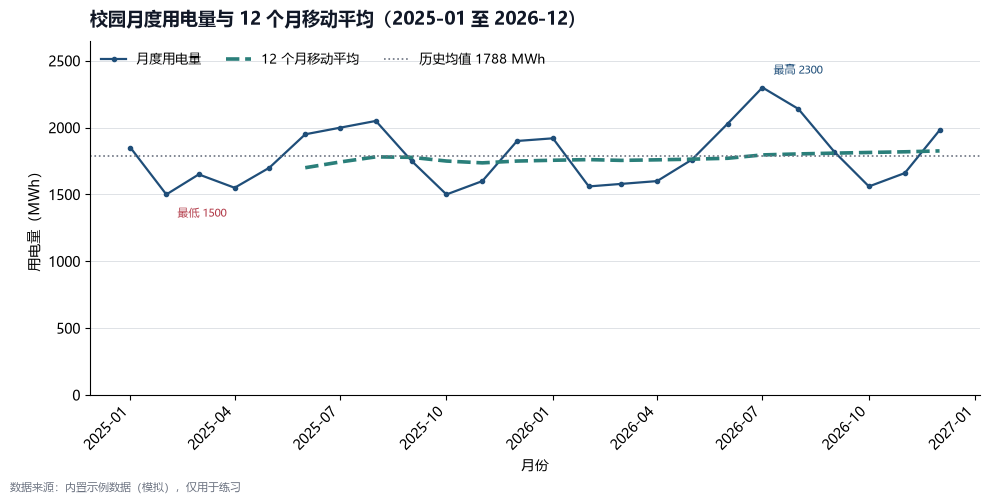

In [4]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(df[DATE_COL], df[VALUE_COL], color="#1F4E79", linewidth=1.6,
        marker="o", markersize=3, label="月度用电量")
ax.plot(df[DATE_COL], df["ma12"], color="#2A7F7A", linestyle="--",
        linewidth=2.6, label="12 个月移动平均")

values = np.asarray(df[VALUE_COL], dtype=float)
mean_value = float(np.nanmean(values))
ax.axhline(mean_value, color="#6B7280", linestyle=":", linewidth=1.2,
           label=f"历史均值 {mean_value:.0f} MWh")

max_pos = int(np.argmax(values))
min_pos = int(np.argmin(values))
max_value = float(values[max_pos])
min_value = float(values[min_pos])
max_date = pd.Timestamp(df[DATE_COL].iloc[max_pos])
min_date = pd.Timestamp(df[DATE_COL].iloc[min_pos])
ax.annotate(f"最高 {max_value:.0f}",
            xy=(max_date, max_value),
            xytext=(8, 10), textcoords="offset points",
            fontsize=8, color="#1F4E79")
ax.annotate(f"最低 {min_value:.0f}",
            xy=(min_date, min_value),
            xytext=(8, -16), textcoords="offset points",
            fontsize=8, color="#B23A48")

start = df[DATE_COL].min().strftime("%Y-%m")
end = df[DATE_COL].max().strftime("%Y-%m")
ax.set_title(f"校园月度用电量与 12 个月移动平均（{start} 至 {end}）",
             loc="left", fontsize=13, fontweight="bold",
             color="#111827", pad=12)
ax.set_xlabel("月份", fontsize=10)
ax.set_ylabel("用电量（MWh）", fontsize=10)
ax.set_ylim(0, float(np.nanmax(values)) * 1.15)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, ncol=3, loc="upper left", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
fig.autofmt_xdate(rotation=45)
fig.text(0.01, 0.015, f"数据来源：{SOURCE_NOTE}", fontsize=8, color="#6B7280")
fig.subplots_adjust(left=0.09, right=0.98, top=0.88, bottom=0.20)
fig.savefig(CHARTS_DIR / "energy_trend.png", dpi=200, bbox_inches="tight")
plt.show()

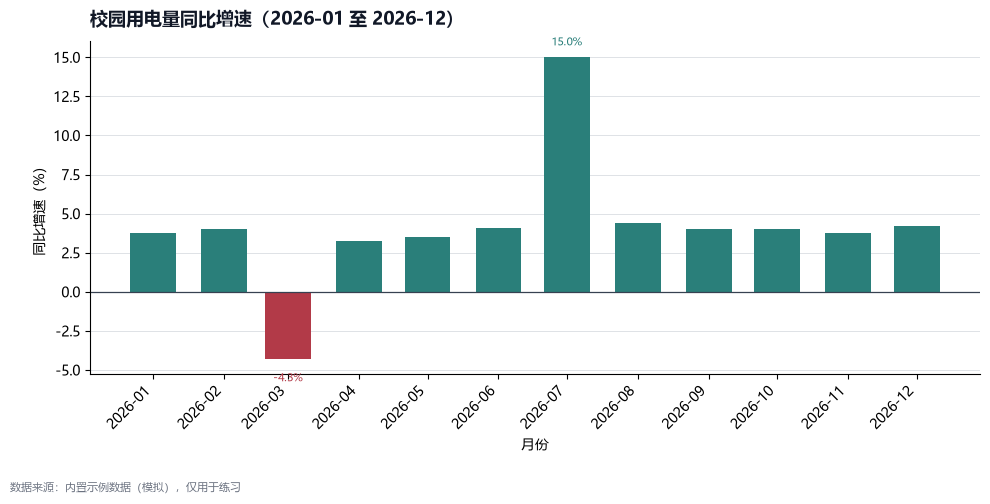

In [5]:
import matplotlib.dates as mdates

yoy = df.dropna(subset=["yoy_growth"]).copy()
yoy_values = np.asarray(yoy["yoy_growth"], dtype=float) * 100
colors = ["#2A7F7A" if v >= 0 else "#B23A48" for v in yoy_values]

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.bar(yoy[DATE_COL], yoy_values, color=colors, width=20)
ax.axhline(0, color="#374151", linewidth=0.9)

max_pos = int(np.argmax(yoy_values))
min_pos = int(np.argmin(yoy_values))
for pos, offset in [(max_pos, 8), (min_pos, -16)]:
    value = float(yoy_values[pos])
    date = pd.Timestamp(yoy[DATE_COL].iloc[pos])
    ax.annotate(f"{value:.1f}%", xy=(date, value),
                xytext=(0, offset), textcoords="offset points",
                ha="center", fontsize=8,
                color="#2A7F7A" if value >= 0 else "#B23A48")

date_values = yoy[DATE_COL].to_numpy()
start = pd.Timestamp(date_values.min()).strftime("%Y-%m")
end = pd.Timestamp(date_values.max()).strftime("%Y-%m")
ax.set_title(f"校园用电量同比增速（{start} 至 {end}）",
             loc="left", fontsize=13, fontweight="bold",
             color="#111827", pad=12)
ax.set_xlabel("月份", fontsize=10)
ax.set_ylabel("同比增速（%）", fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
fig.autofmt_xdate(rotation=45)
fig.text(0.01, 0.015, f"数据来源：{SOURCE_NOTE}", fontsize=8, color="#6B7280")
fig.subplots_adjust(left=0.09, right=0.98, top=0.88, bottom=0.24)
fig.savefig(CHARTS_DIR / "yoy_growth.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
# 保存清洗后的数据和分析摘要
df.to_csv(OUT_DIR / "clean_data.csv", index=False, encoding="utf-8-sig")

lines = ["能源数据分析摘要", "=" * 20, f"数据来源：{SOURCE_NOTE}"]
for key, value in summary.items():
    lines.append(f"{key}：{value}")
lines.extend([
    "",
    "提示：如果使用示例数据，请在报告中写明“模拟数据，仅用于练习”。",
])
(OUT_DIR / "summary.txt").write_text("\n".join(lines), encoding="utf-8")

print("已保存：")
print("-", OUT_DIR / "clean_data.csv")
print("-", OUT_DIR / "summary.txt")
print("-", OUT_DIR / "energy_trend.png")
print("-", OUT_DIR / "yoy_growth.png")

已保存：
- C:\Users\Lenovo\Documents\New project\Three_Year_Plan_2026_2029\Energy_Data_Project\output\clean_data.csv
- C:\Users\Lenovo\Documents\New project\Three_Year_Plan_2026_2029\Energy_Data_Project\output\summary.txt
- C:\Users\Lenovo\Documents\New project\Three_Year_Plan_2026_2029\Energy_Data_Project\output\energy_trend.png
- C:\Users\Lenovo\Documents\New project\Three_Year_Plan_2026_2029\Energy_Data_Project\output\yoy_growth.png


## 下一步

1. 把 `data/monthly_energy_sample.csv` 换成真实数据（国家统计局、中电联、IEA、Our World in Data）。
2. 加入第二个变量（气温、GDP、人口、装机容量），做相关性或简单回归。
3. 把结论写进 `report_template.md`，做成一页报告。
4. 上传到 GitHub，作为转专业面试、节能减排校赛和能源经济大赛的作品。

> 记住：相关性不等于因果；所有数据都要写清来源、时间和口径。